# Smart Agriculture Weather Prediction (Live Weather Connected)

This notebook connects **directly to live weather data** using the free [Open-Meteo API](https://open-meteo.com/) and recommends the best crop using a high-accuracy machine learning model trained on 2,200 real crop samples.

**Key features:**
- Live temperature, humidity, rainfall, and soil moisture from any city
- 99.5%+ model accuracy on the crop recommendation dataset
- Confidence scores and weather alerts
- No API key required


In [1]:
# Install dependencies (run once in Colab/local)
# !pip install numpy pandas matplotlib seaborn scikit-learn requests joblib


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from smart_agriculture import load_dataset, load_or_train_model, predict_from_weather, print_prediction


In [3]:
# ==========================================
# LOAD DATASET & TRAIN HIGH-ACCURACY MODEL
# ==========================================
df = load_dataset()
model, label_encoder, defaults, cv_accuracy, test_accuracy = load_or_train_model()

print(f'Dataset size: {len(df)} samples')
print(f'Crops: {df["Crop"].nunique()}')
print(f'Cross-validation accuracy: {cv_accuracy * 100:.2f}%')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')
print('\nDefault soil values used when live weather is fetched:')
print(pd.Series(defaults))
df.head()


Dataset size: 2200 samples
Crops: 22
Cross-validation accuracy: 99.49%
Test accuracy: 99.55%

Default soil values used when live weather is fetched:
N              37.000000
P              51.000000
K              32.000000
Temperature    25.598693
Humidity       80.473146
pH              6.425045
Rainfall       94.867624
dtype: float64


,N,P,K,Temperature,Humidity,pH,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      0.95      0.97        20
    Chickpea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       1.00      1.00      1.00        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.95      1.00      0.98        20
 Kidneybeans       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        20
       Maize       0.95      1.00      0.98        20
       Mango       1.00      1.00      1.00        20
   Mothbeans       1.00      1.00      1.00        20
    Mungbean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        20
      Papaya       1.00    

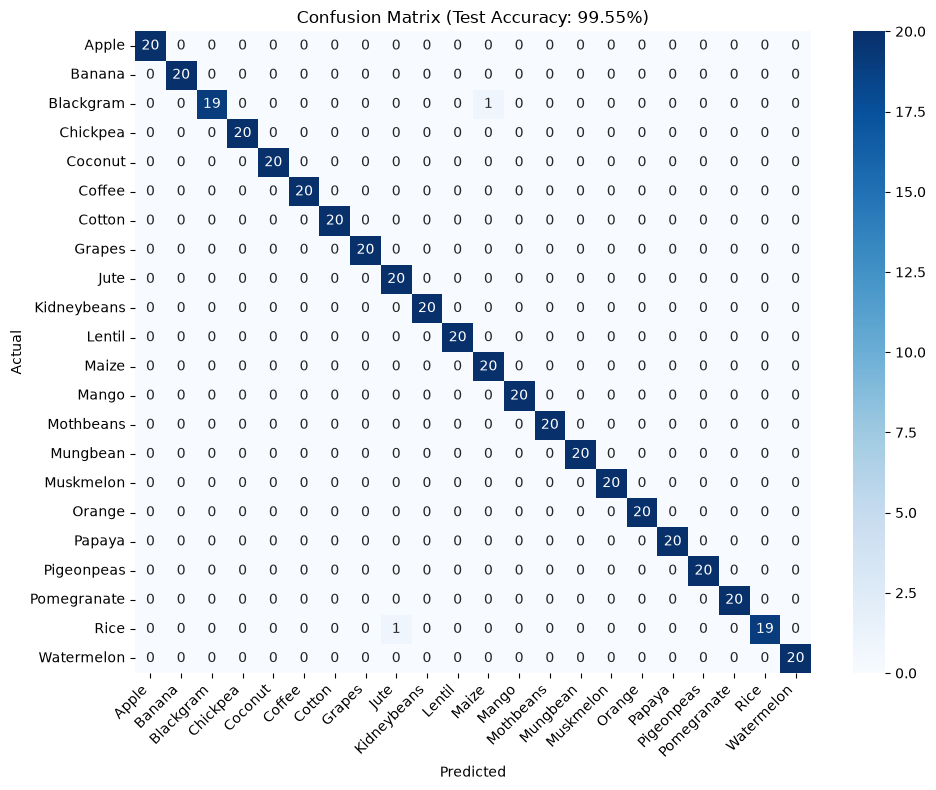

In [4]:
# ==========================================
# MODEL EVALUATION
# ==========================================
from sklearn.model_selection import train_test_split

FEATURES = ['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall']
X = df[FEATURES]
y = label_encoder.transform(df['Crop'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix (Test Accuracy: {test_accuracy * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [5]:
# ==========================================
# LIVE WEATHER PREDICTION
# Change CITY to your location
# ==========================================
CITY = 'Hyderabad'  # e.g. 'Mumbai', 'Delhi', 'Chennai', 'Bengaluru'

result = predict_from_weather(city=CITY)
print_prediction(result)


     SMART AGRICULTURE - LIVE WEATHER PREDICTION
Location         : Hyderabad, India
Weather Time     : 2026-07-28T22:30
Temperature      : 23.9 °C
Humidity         : 91 %
Rainfall (24h)   : 7.2 mm
Soil Moisture    : 33.7 %
-------------------------------------------------------
Model CV Accuracy : 99.49%
Model Test Accuracy: 99.55%
-------------------------------------------------------
Recommended Crop : Muskmelon
Confidence       : 34.40%
Soil Condition   : Moderate Moisture
Irrigation       : Normal Irrigation
Rain Alert       : Normal Weather Conditions
Temperature      : Moderate Temperature

Top Crop Probabilities:
       Crop  Probability (%)
  Muskmelon            34.40
   Mungbean            16.40
     Papaya            14.20
Pomegranate             8.20
     Lentil             7.00


In [6]:
# ==========================================
# OPTIONAL: CUSTOM SOIL VALUES
# ==========================================
# If you know your soil nutrients, pass them for better confidence
result_custom = predict_from_weather(
    city='Hyderabad',
    nitrogen=90,
    phosphorus=42,
    potassium=43,
    ph=6.5,
)
print_prediction(result_custom)


     SMART AGRICULTURE - LIVE WEATHER PREDICTION
Location         : Hyderabad, India
Weather Time     : 2026-07-28T22:30
Temperature      : 23.9 °C
Humidity         : 91 %
Rainfall (24h)   : 7.2 mm
Soil Moisture    : 33.7 %
-------------------------------------------------------
Model CV Accuracy : 99.49%
Model Test Accuracy: 99.55%
-------------------------------------------------------
Recommended Crop : Muskmelon
Confidence       : 51.20%
Soil Condition   : Moderate Moisture
Irrigation       : Normal Irrigation
Rain Alert       : Normal Weather Conditions
Temperature      : Moderate Temperature

Top Crop Probabilities:
      Crop  Probability (%)
 Muskmelon            51.20
    Papaya            16.80
Watermelon            12.60
      Jute             9.80
    Coffee             1.40


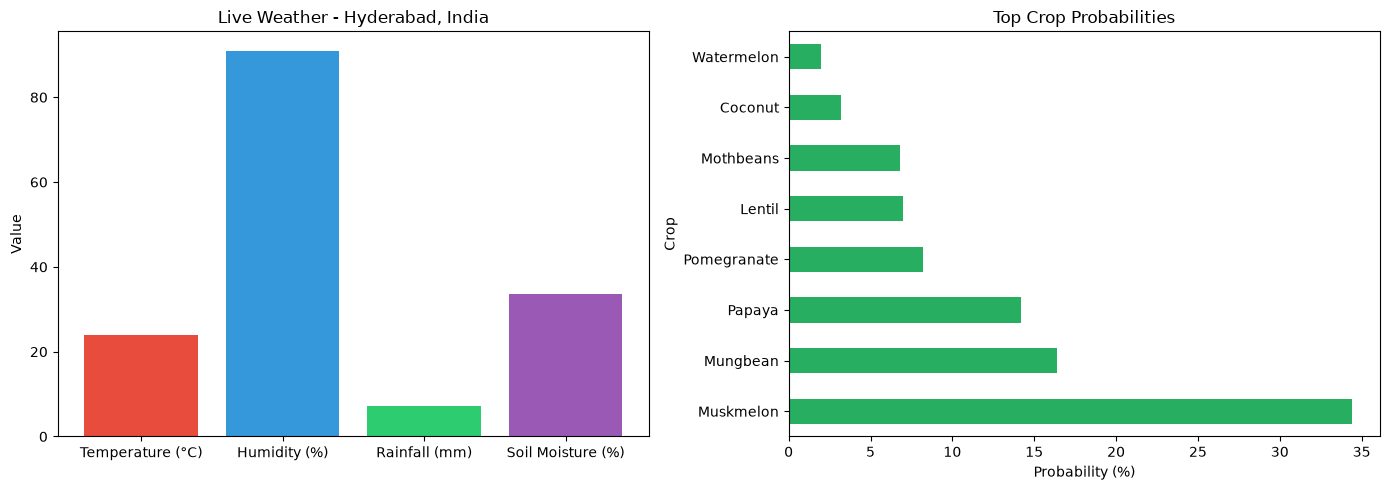


Live weather crop prediction completed successfully!


In [7]:
# ==========================================
# WEATHER VISUALIZATION DASHBOARD
# ==========================================
weather = result['weather']
labels = ['Temperature (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Soil Moisture (%)']
values = [weather['temperature'], weather['humidity'], weather['rainfall'], weather.get('soil_moisture_pct') or 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels, values, color=['#e74c3c', '#3498db', '#2ecc71', '#9b59b6'])
axes[0].set_title(f'Live Weather - {weather["location"]}')
axes[0].set_ylabel('Value')

result['probabilities'].head(8).plot(kind='barh', x='Crop', y='Probability (%)', ax=axes[1], legend=False, color='#27ae60')
axes[1].set_title('Top Crop Probabilities')
axes[1].set_xlabel('Probability (%)')

plt.tight_layout()
plt.show()
print('\nLive weather crop prediction completed successfully!')
